In [1]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import dill
from tqdm import tqdm
import os

from analyze.report import plot_sound, POPULATION_COLORS, draw_spikes_and_psth_bothside, draw_rate_vs_cue, plot_tonotopic_heatmaps
from utils.custom_sounds import Tone, Click_Train, WhiteNoise
import brian2 as b2
import brian2hears as b2h

2026-07-15 22:32:48,189 [INFO ]  

>>>>> start execution
✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1



How to cite *cochlea*:

Rudnicki M. and Hemmert W. (2009—). Cochlea: inner ear models in
Python.  https://github.com/mrkrd/cochlea/

@Misc{Rudnicki2009-Cochlea,
  author       = {Rudnicki, M. and Hemmert, W.},
  title        = {Cochlea: inner ear models in Python},
  year         = {2009--},
  howpublished = {https://github.com/mrkrd/cochlea},
  url          = {https://github.com/mrkrd/cochlea},
}



In [2]:
folder_dir = '/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/results/artificial_itd/LSO/'
# '/Users/francescodesantis/Documents/repos/sound_localization_model/results/artificial_itd/'
# '/Users/francescodesantis/Desktop/cineca_results/'

# List directory contents
items = os.listdir(folder_dir)
items = sorted(items)
for i, item in enumerate(items):
    print(i, item)


0 .DS_Store
1 tau_decay_inh_1
2 we_0.8_wi_-2.3
3 we_1_wi_-2.3
4 we_2_wi_-10
5 we_4_wi_-10
6 we_4_wi_-30
7 we_5_wi_-100
8 we_5_wi_-120
9 we_5_wi_-150
10 we_5_wi_-80
11 we_6_wi_-80


In [3]:
folder = items[10]
pop = 'LSO'
x_ax = 'itd'
cf_nuc = 160 if pop == 'LSO' else 440

In [4]:
folder

'we_5_wi_-80'

In [5]:
results_dir =  folder_dir + folder + '/'
# '/Users/francescodesantis/Documents/repos/sound_localization_model/results/artificial_itd/LSO/d_0.78/we_1/'
# '/Users/francescodesantis/Desktop/cineca_results/'

# List directory contents
items2 = os.listdir(results_dir)
items2 = sorted(items2)
for i, item in enumerate(items2):
    print(i, item)


0 .DS_Store
1 click_train_interval_5. ms_70dB&d0.78_seed0_multimeters.pic
2 click_train_interval_5. ms_70dB&d_0.78_seed_0.pic
3 click_train_interval_5. ms_70dB&d_0.78_seed_1.pic
4 click_train_interval_5. ms_70dB&d_0.78_seed_10.pic
5 click_train_interval_5. ms_70dB&d_0.78_seed_11.pic
6 click_train_interval_5. ms_70dB&d_0.78_seed_12.pic
7 click_train_interval_5. ms_70dB&d_0.78_seed_13.pic
8 click_train_interval_5. ms_70dB&d_0.78_seed_14.pic
9 click_train_interval_5. ms_70dB&d_0.78_seed_15.pic
10 click_train_interval_5. ms_70dB&d_0.78_seed_16.pic
11 click_train_interval_5. ms_70dB&d_0.78_seed_17.pic
12 click_train_interval_5. ms_70dB&d_0.78_seed_18.pic
13 click_train_interval_5. ms_70dB&d_0.78_seed_19.pic
14 click_train_interval_5. ms_70dB&d_0.78_seed_2.pic
15 click_train_interval_5. ms_70dB&d_0.78_seed_20.pic
16 click_train_interval_5. ms_70dB&d_0.78_seed_3.pic
17 click_train_interval_5. ms_70dB&d_0.78_seed_4.pic
18 click_train_interval_5. ms_70dB&d_0.78_seed_5.pic
19 click_train_interva

In [ ]:
id_items = range(23,43)
# array = []
results = []

for i, id in enumerate(id_items):
    file_name = items2[id]
    result_path = results_dir +  file_name 

    with open(result_path, "rb") as file:
        result = dill.load(file, ignore=True)
    print(f"{file_name} loaded")
    results.append(result)
array.append(results)


click_train_interval_5. ms_70dB&d_1.28_seed_0.pic loaded
click_train_interval_5. ms_70dB&d_1.28_seed_1.pic loaded
click_train_interval_5. ms_70dB&d_1.28_seed_11.pic loaded


In [7]:
for i in range(len(array)):
    result = array[i][0]
    if pop == 'MSO':
        print('----------------------')
        print(result['conf']['parameters']['POP_CONV']['MNTBCs2MSOs'])

        print(result['conf']['parameters']['SYN_WEIGHTS']['SBCs2MSO'])
        print(result['conf']['parameters']['SYN_WEIGHTS']['MNTBCs2MSO'])

        print(result['conf']['parameters']['E_L']['MSO'])
        print(result['conf']['parameters']['INH_REV']['MSO'])

        print(result['conf']['parameters']['TAUS_EX_RISE']['MSO'])
        print(result['conf']['parameters']['TAUS_EX_DECAY']['MSO'])
        print(result['conf']['parameters']['TAUS_IN_RISE']['MSO'])
        print(result['conf']['parameters']['TAUS_IN_DECAY']['MSO'])
    else:
        print(result['conf']['parameters']['SYN_WEIGHTS']['SBCs2LSO'])
        print(result['conf']['parameters']['SYN_WEIGHTS']['MNTBCs2LSO'])
        print(result['conf']['parameters']['SYN_DELAYS']['MNTBCs2LSO'])



5
-80
0.78


In [8]:
cue_values = np.asarray(list(result['cue_to_rate'].keys()))

print("original level:", round(result['sounds']['base_sound'].sound.level,2))
print("left level:", round(result['sounds']['left_sounds'][cue_values[0]].level,2))
print("right level:", round(result['sounds']['right_sounds'][cue_values[0]].level,2))



original level: 51.65
left level: 51.31
right level: 51.31


-0.005 ms


(<Figure size 500x300 with 1 Axes>,
 <Axes: xlabel='Time (ms)', ylabel='Amplitude'>)

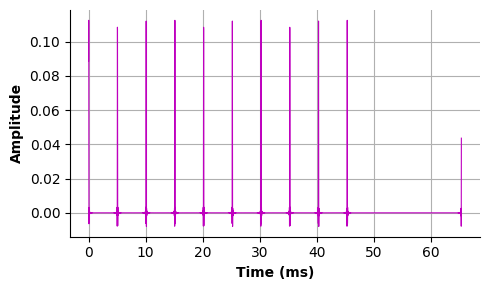

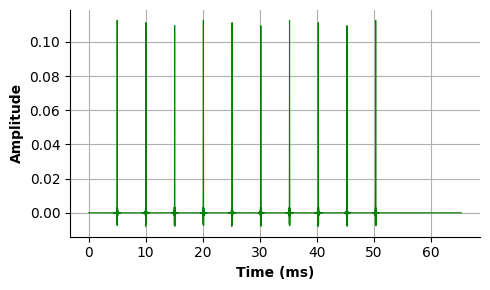

In [9]:
c = cue_values[0]
print(c, 'ms')
plot_sound(array[0][0]['sounds']['left_sounds'][c], colors=['m'], figsize=(5,3))
plot_sound(array[0][0]['sounds']['right_sounds'][c], colors=['g'], figsize=(5,3))

In [10]:
if isinstance(result['sounds']['base_sound'], Tone):
    print("Base sound is a tone with frequency:", result['sounds']['base_sound'].frequency, "Hz")
    f = result['sounds']['base_sound'].frequency / b2.Hz
    CF_low  = f * 2**(-0.5)   
    CF_high = f * 2**(+0.5)   #4200 neurons around the CF, 2100 on each side
    cf_interval = [CF_low, CF_high]
    print(f"CF interval: {cf_interval[0]:.2f} Hz - {cf_interval[1]:.2f} Hz")
else:
    print("Base sound is not a tone, cannot determine CF interval.")
    cf_interval = None
    f = 14000

d = max(
    max(result['sounds']['left_sounds'][cue].duration / b2.ms for cue in result['cue_to_rate']),
    max(result['sounds']['right_sounds'][cue].duration / b2.ms for cue in result['cue_to_rate'])
)
print("Max sound duration (ms):", d)

bin_s = 0.5
rast_s = 1

Base sound is not a tone, cannot determine CF interval.
Max sound duration (ms): 65.32000000000001


In [11]:
from analyze.report import get_avg_rate_vs_cue, extract_best_itd_ipd, plot_best_itd_ipd_vs_freq

if pop == 'MSO':
    max_itds = []
    bws = [10,10,10,10,10,10,10,10,10,10]
    for i, bw in enumerate(bws):
        f = array[i][0]['sounds']['base_sound'].frequency / b2.Hz

        draw_rate_vs_cue(
            data=array[i],
            pop= pop,
            side = 'L',
            rate = 'avg',
            cue_type = x_ax,
            # target_cf_hz = f,
            center_cf = f,
            bw_neurons = bw,
        )

        curve = get_avg_rate_vs_cue(array[i], pop='MSO', side='L', center_cf=f, bw_neurons=10, rate='avg')
        print(extract_best_itd_ipd(curve, f))
        max_itds.append(extract_best_itd_ipd(curve, f))
        print(f"max rate: {np.max(curve['rate'])} at cue: {curve['cues'][np.argmax(curve['rate'])]}")

    plot_best_itd_ipd_vs_freq(max_itds)

In [12]:
from analyze.report import get_avg_rate_vs_cue, extract_ild50_metrics, plot_ild50_fit, extract_first_spike_latency_metrics

if (pop == 'LSO' and x_ax == 'ild_exp'):
    metrics = extract_first_spike_latency_metrics(
        results, pop='LSO', side='L', cue=0,
        center_cf=f, onset_time=.0, window=[5.0, 25.0],
    )
    print(f"median latency={metrics['median_latency']:.2f} ms, "
        f"jitter (IQR)={metrics['jitter_iqr']:.2f} ms, "
        f"n={metrics['n_responses']}/{metrics['n_reps']}")


    freq_array = []
    max_rate_array = []
    min_rate_array = []
    ild50_array = []
    first_spike_latency_array = []
    jitter_array = []


    for i in range(len(array)):
        results = array[i]
        f = results[0]['sounds']['base_sound'].frequency / b2.Hz

        curve = get_avg_rate_vs_cue(results, pop='LSO', side='L', center_cf=f, bw_neurons=0)
        metrics = extract_ild50_metrics(curve["cues"], curve["rate"], ipsi_ref='min', normalize=True)
        metrics_fsl = extract_first_spike_latency_metrics( results, pop='LSO', side='L', cue=0, center_cf=f, onset_time=.0, window=[5.0, 25.0])
        ipsi_level = results[0]['sounds']['left_sounds'][90.0].level
        ild50_db = ipsi_level - metrics["ild50"] * b2h.dB

        freq_array.append(f)
        min_rate_array.append(metrics["min_rate"])
        max_rate_array.append(metrics["max_rate"])
        ild50_array.append(ild50_db)
        first_spike_latency_array.append(metrics_fsl["median_latency"])
        jitter_array.append(metrics_fsl["jitter_iqr"])
        draw_rate_vs_cue(
            data=results,
            pop= pop,
            rate = 'avg',
            cue_type = x_ax,
            target_cf_hz = f,
            center_cf = f,
            bw_neurons = 10,
            cf_interval= cf_interval,
            )
        plot_ild50_fit(metrics, sem=curve["sem"])
        print("TONE FREQ: ", f/1000, "kHz")
        print("MAX FR: ", round(metrics["max_rate"], 2), "Hz")
        print("MIN FR: ", round(metrics["min_rate"], 2), "Hz")
        print("IPSI_LEV: ", round(ipsi_level, 4), "dB")
        print("ILD_50: ", round(ild50_db, 4), "dB")
        print("FIRST SPIKE LATENCY: ", round(metrics_fsl["median_latency"], 2), "ms")
        print("JITTER: ", round(metrics_fsl["jitter_iqr"], 2), "ms")
        print('----------------------')

    max_rate_avg = np.mean(max_rate_array)
    min_rate_avg = np.mean(min_rate_array)
    ild50_avg = np.mean(ild50_array)
    first_spike_latency_avg = np.mean(first_spike_latency_array)
    jitter_avg = np.mean(jitter_array)

    print("AVERAGE MAX FR: ", round(max_rate_avg, 2), "Hz\n",
        "AVERAGE MIN FR: ", round(min_rate_avg, 2), 'Hz\n',
        "AVERAGE ILD_50: ", round(ild50_avg, 2), "dB")
    print("AVERAGE FIRST SPIKE LATENCY: ", round(first_spike_latency_avg, 2), "ms")
    print("AVERAGE JITTER: ", round(jitter_avg, 2), "ms")

    # --- Sort by frequency for clean line plots ---
    sort_idx = np.argsort(freq_array)
    freq_sorted = np.array(freq_array)[sort_idx]
    max_sorted = np.array(max_rate_array)[sort_idx]
    min_sorted = np.array(min_rate_array)[sort_idx]
    ild50_sorted = np.array(ild50_array)[sort_idx]

    fig, axes = plt.subplots(1,figsize=(8, 4))
    axes.plot(freq_sorted/1000, max_sorted, 'o-', color='tab:blue')
    axes.set_xlabel("Frequency (kHz)")
    axes.set_ylabel("Max firing rate (Hz)")
    axes.set_title("Max FR vs Frequency")
    fig, axes = plt.subplots(1,figsize=(8, 4))
    axes.plot(freq_sorted/1000, min_sorted, 'o-', color='tab:orange')
    axes.set_xlabel("Frequency (kHz)")
    axes.set_ylabel("Min firing rate (Hz)")
    axes.set_title("Min FR vs Frequency")
    fig, axes = plt.subplots(1,figsize=(8, 4))
    axes.plot(freq_sorted/1000, ild50_sorted, 'o-', color='tab:green')
    axes.set_xlabel("Frequency (kHz)")
    axes.set_ylabel("ILD50 (dB)")
    axes.set_title("ILD50 vs Frequency")
    fig, axes = plt.subplots(1,figsize=(8, 4))
    axes.plot(freq_sorted/1000, first_spike_latency_array, 'o-', color='tab:red')
    axes.set_xlabel("Frequency (kHz)")
    axes.set_ylabel("First Spike Latency (ms)")
    axes.set_title("First Spike Latency vs Frequency")  
    fig, axes = plt.subplots(1,figsize=(8, 4))
    axes.plot(freq_sorted/1000, jitter_array, 'o-', color='tab:purple')
    axes.set_xlabel("Frequency (kHz)")
    axes.set_ylabel("Jitter (ms)")
    axes.set_title("Jitter vs Frequency")

    plt.tight_layout()
    plt.show()

In [13]:
if (pop == 'LSO' and x_ax == 'ild_exp'):
    freq_array = []
    max_rate_array = []
    min_rate_array = []
    ild50_array = []
    first_spike_latency_array = []
    jitter_array = []
    raw_curves = []

    for i in range(len(array)):
        results = array[i]
        f = results[0]['sounds']['base_sound'].frequency / b2.Hz
        curve = get_avg_rate_vs_cue(results, pop='LSO', side='L', center_cf=f, bw_neurons=0)
        metrics = extract_ild50_metrics(curve["cues"], curve["rate"], ipsi_ref='min', normalize=False)
        metrics_fsl = extract_first_spike_latency_metrics(
            results, pop='LSO', side='L', cue=0, center_cf=f, onset_time=.0, window=[5.0, 25.0]
        )
        ipsi_level = results[0]['sounds']['left_sounds'][90.0].level
        ild50_db = ipsi_level - metrics["ild50"] * b2h.dB

        freq_array.append(f)
        min_rate_array.append(metrics["min_rate"])
        max_rate_array.append(metrics["max_rate"])
        ild50_array.append(ild50_db)
        first_spike_latency_array.append(metrics_fsl["median_latency"])
        jitter_array.append(metrics_fsl["jitter_iqr"])
        raw_curves.append(curve)

    # --- normalize all curves to the max of maxima across the population ---
    pop_max = np.max(max_rate_array)

    metrics_norm_array = []
    ild50_norm_array = []
    ipsi_levels = []

    for i in range(len(array)):
        results = array[i]
        curve = raw_curves[i]
        rate_norm = curve["rate"] / pop_max * 100.0

        metrics_norm = extract_ild50_metrics(
            curve["cues"], rate_norm, ipsi_ref='min', normalize=False
        )
        ipsi_level = results[0]['sounds']['left_sounds'][90.0].level
        ild50_db_norm = ipsi_level - metrics_norm["ild50"] * b2h.dB

        metrics_norm_array.append(metrics_norm)
        ild50_norm_array.append(ild50_db_norm)
        ipsi_levels.append(ipsi_level)

    print("ILD50 (normalized to population max):")
    for f, ild in zip(freq_array, ild50_norm_array):
        print(f"  {f/1000:.2f} kHz -> ILD50 = {ild:.2f} dB")

    ild50_norm_avg = np.mean(ild50_norm_array)
    print(f"\nAVERAGE ILD50 (normalized): {ild50_norm_avg:.2f} dB")

    # --- plot all normalized sigmoid fits together ---
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = plt.cm.viridis(np.linspace(0, 1, len(array)))

    for i in range(len(array)):
        curve = raw_curves[i]
        metrics_norm = metrics_norm_array[i]
        fit_fn = metrics_norm["fit_curve_fn"]

        x_fit = np.linspace(curve["cues"].min(), curve["cues"].max(), 200)
        y_fit = fit_fn(x_fit)

        ax.plot(curve["cues"], metrics_norm["rate"], 'o', color=cmap[i], ms=4, alpha=0.6)
        ax.plot(x_fit, y_fit, '-', lw=2,
                label=f"{freq_array[i]/1000:.2f} kHz (ILD50={ild50_norm_array[i]:.1f} dB)")

    ax.set_xlabel("Contralateral Level [dB]")
    ax.set_ylabel("Rate normalized to population max [%]")
    ax.set_title("ILD sigmoid fits normalized to population maximum")
    ax.legend(loc='best', fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

[draw_single_neuron_raster] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz
[draw_single_neuron_raster] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz
[draw_single_neuron_raster] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz
[draw_single_neuron_raster] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz
[draw_single_neuron_raster] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz


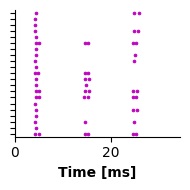

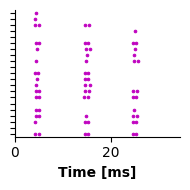

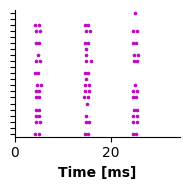

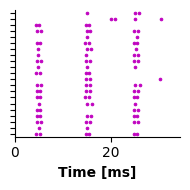

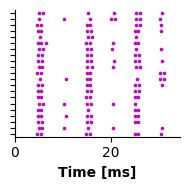

In [41]:
from analyze.report import draw_single_neuron_raster_xpaper #0.00019999999999999998
for i in range(11,16):
    c = cue_values[i]
    draw_single_neuron_raster_xpaper(
        data_list=results,
        cue = c,
        pop = pop,
        side = 'L',
        target_cf_hz= f,
        xlim=[0,34.5],
        figsize=[2,2]
    )

[draw_rate_vs_cue] target_cf_hz=14000 Hz → neuron idx 5133 → cf_interval=[14003.2, 14003.4] Hz


NameError: name 'base_title' is not defined

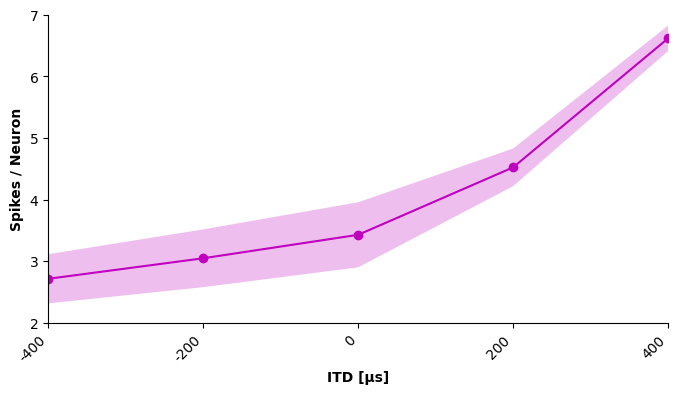

In [47]:
from analyze.report import draw_rate_vs_cue

draw_rate_vs_cue(
    data=array[0],
    pop= pop,
    rate = 'spk_pn',
    side = 'L',
    cue_type = x_ax,
    target_cf_hz = f,
    # center_cf = f,
    # bw_neurons = 10,
    # cf_interval= cf_interval,
    xlim = [-400,400],
    ylim = [2,7],
    time_interval=[0,34.5],
    title = [],
    label = [],
    figsize=[8,4]
    )

WARNING    /Users/francescodesantis/Documents/repos/sound_localization_model/plot/analyze/report.py:2435: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
 [py.warnings]


[draw_single_neuron_raster_by_cue] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz


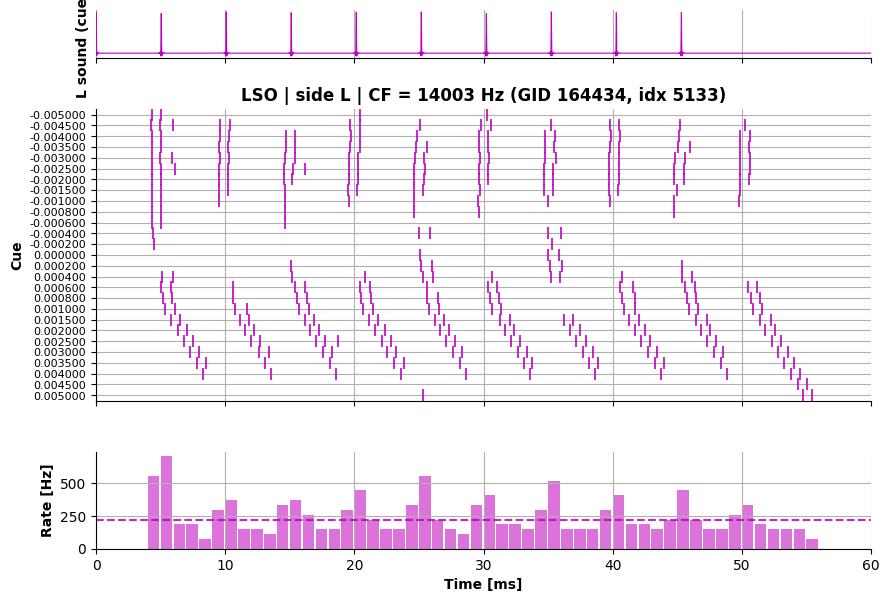

In [16]:
from analyze.report import draw_single_neuron_raster_by_cue

fig, axes = draw_single_neuron_raster_by_cue(
    results[0], pop='LSO', side='L', target_cf_hz=f,
)


In [18]:
for c in cue_values:
    metrics_fsl = extract_first_spike_latency_metrics(array[0], pop='LSO', side='L', cue=c, center_cf=f, onset_time=.0, window=[0, 10.0])
    print(c, metrics_fsl["median_latency"])

-0.005 4.32
-0.0045 4.3100000000000005
-0.004 4.33
-0.0034999999999999996 4.33
-0.003 4.32
-0.0025 4.34
-0.002 4.34
-0.0015 4.32
-0.001 4.33
-0.0007999999999999999 4.33
-0.0006 4.33
-0.00039999999999999996 4.33
-0.00019999999999999998 4.3500000000000005
0.0 4.37
0.00019999999999999998 4.63
0.00039999999999999996 4.83
0.0006 4.98
0.0007999999999999999 5.15
0.001 5.3500000000000005
0.0015 5.82
0.002 6.3100000000000005
0.0025 6.8
0.003 7.3
0.0034999999999999996 7.8100000000000005
0.004 8.3
0.0045 8.754999999999999
0.005 nan


In [19]:
for c in cue_values:
    metrics_fsl = extract_first_spike_latency_metrics(array[1], pop='LSO', side='L', cue=c, center_cf=f, onset_time=.0, window=[0, 10.0])
    print(c, metrics_fsl["median_latency"])

IndexError: list index out of range

WARNING    /var/folders/ll/11knr8bs6_nbxy20yw3f5kfh0000gn/T/ipykernel_29876/2349585057.py:26: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
 [py.warnings]


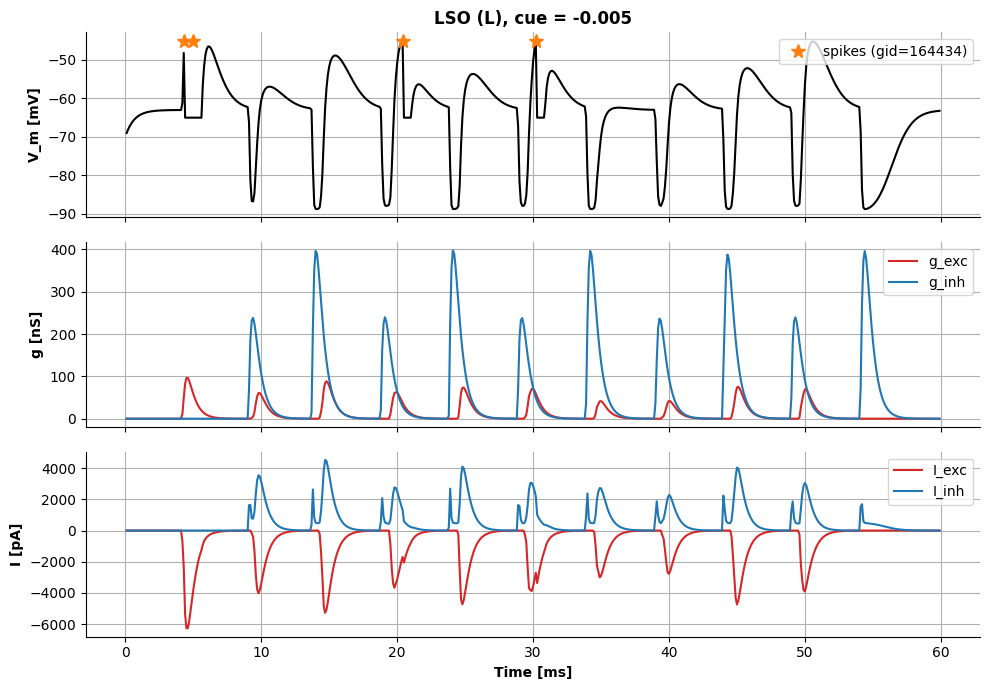

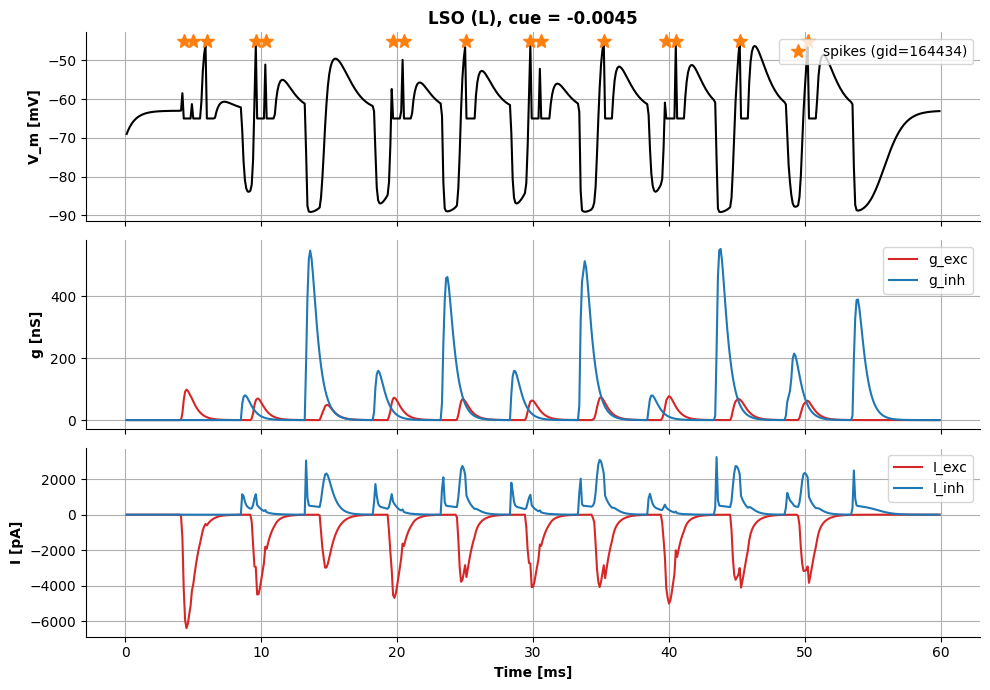

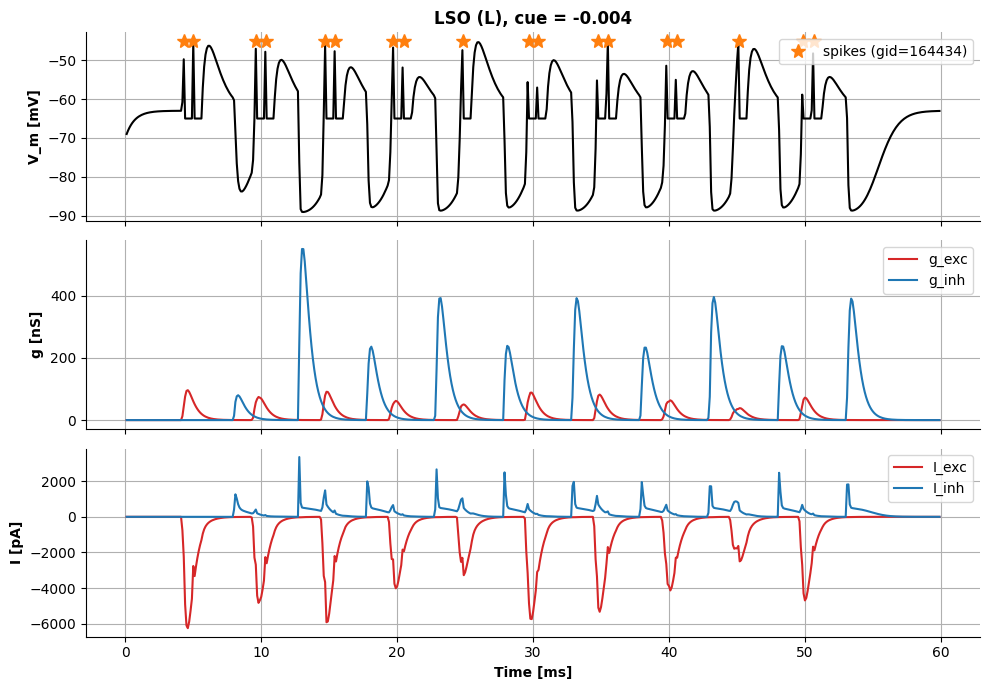

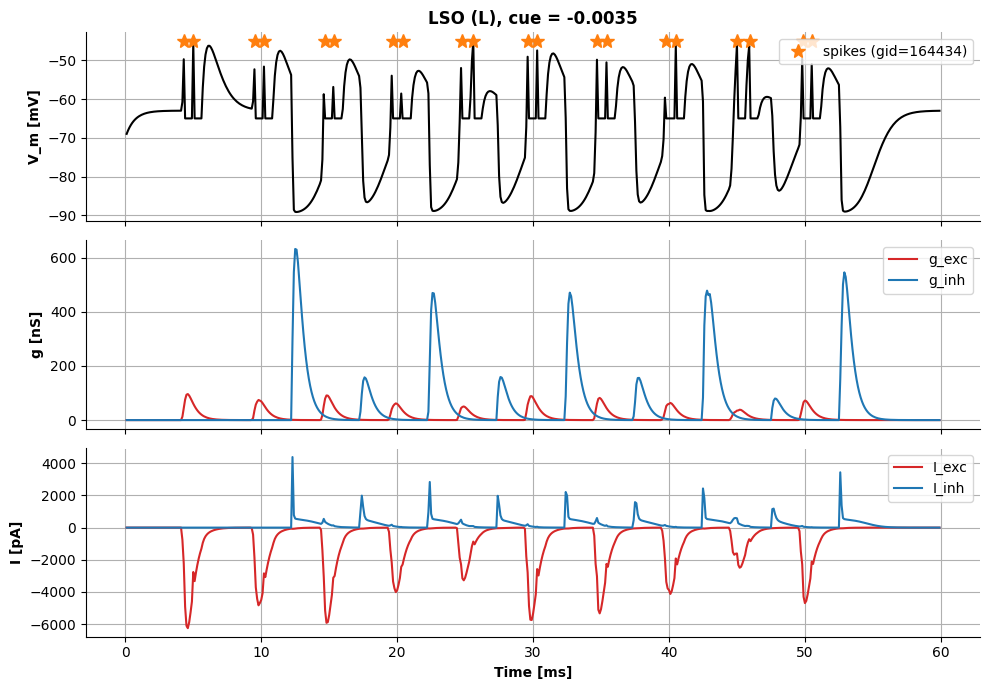

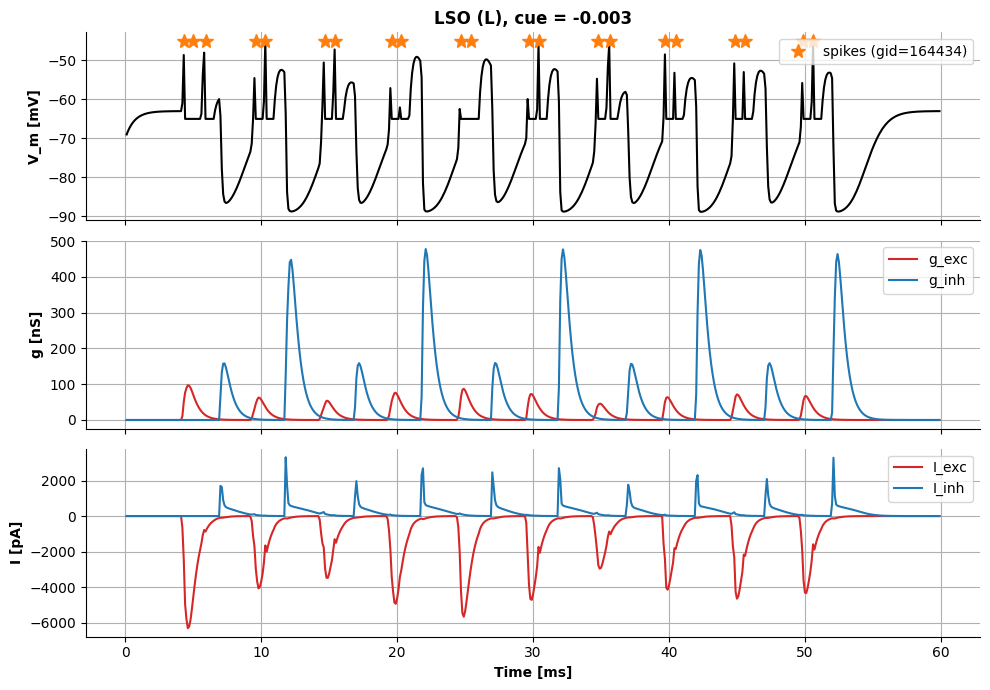

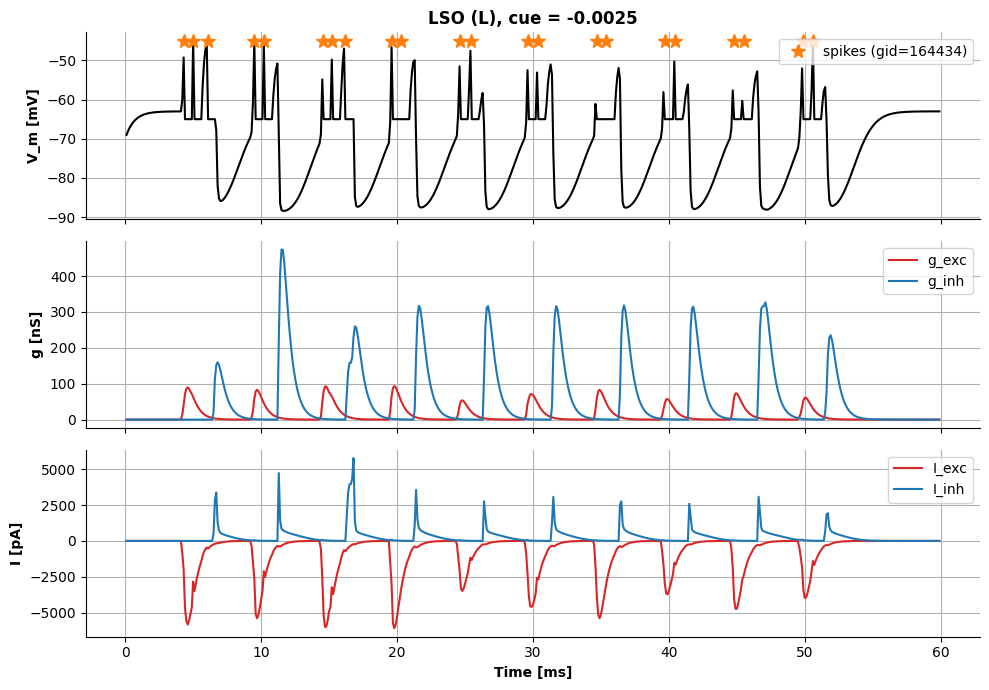

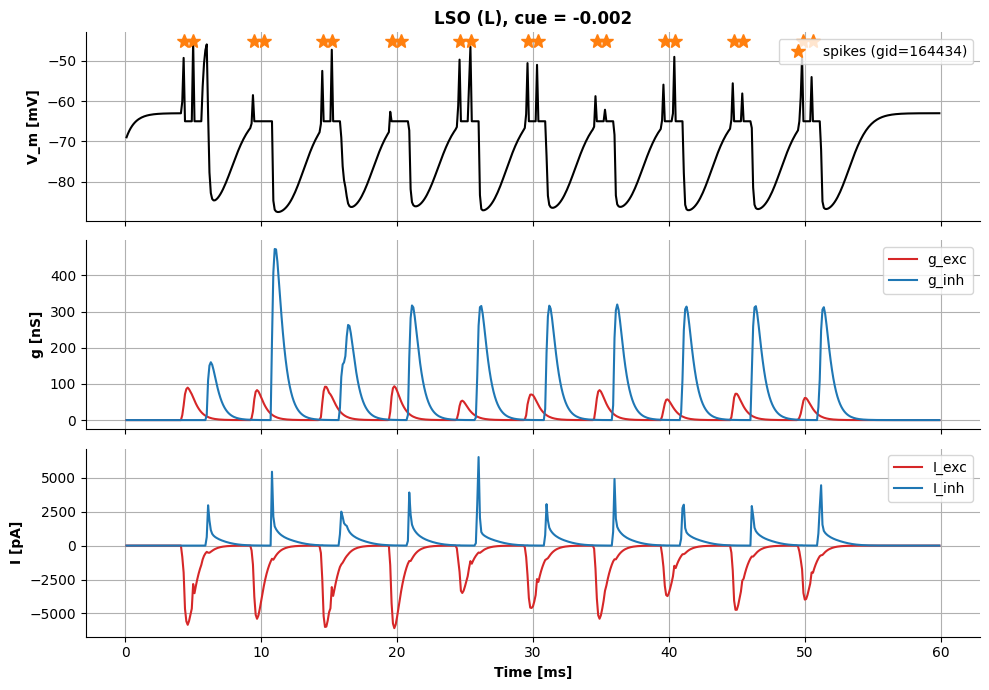

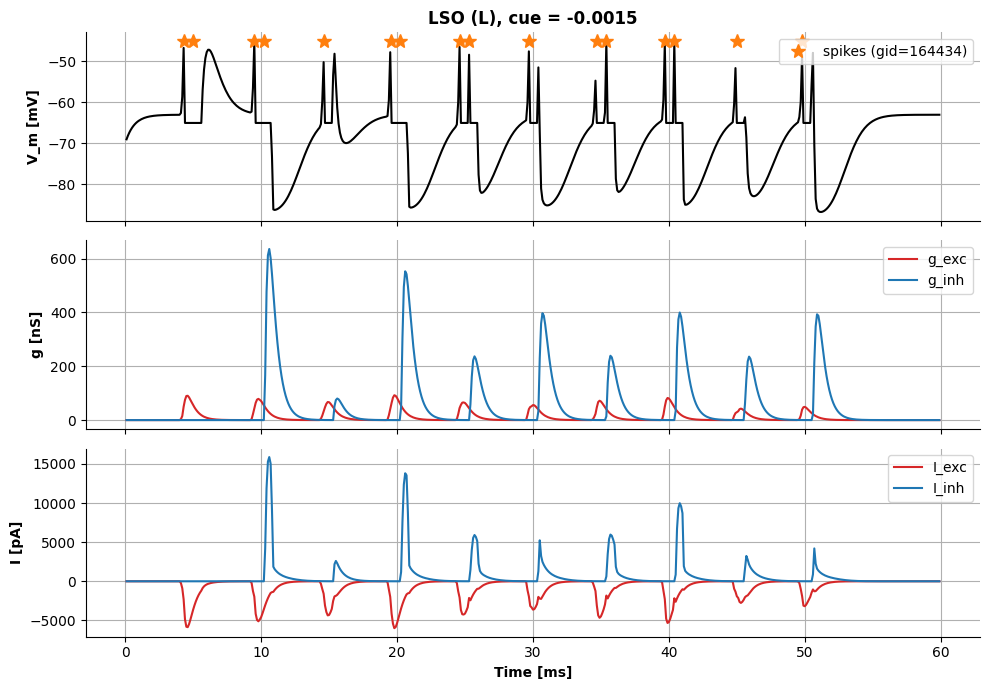

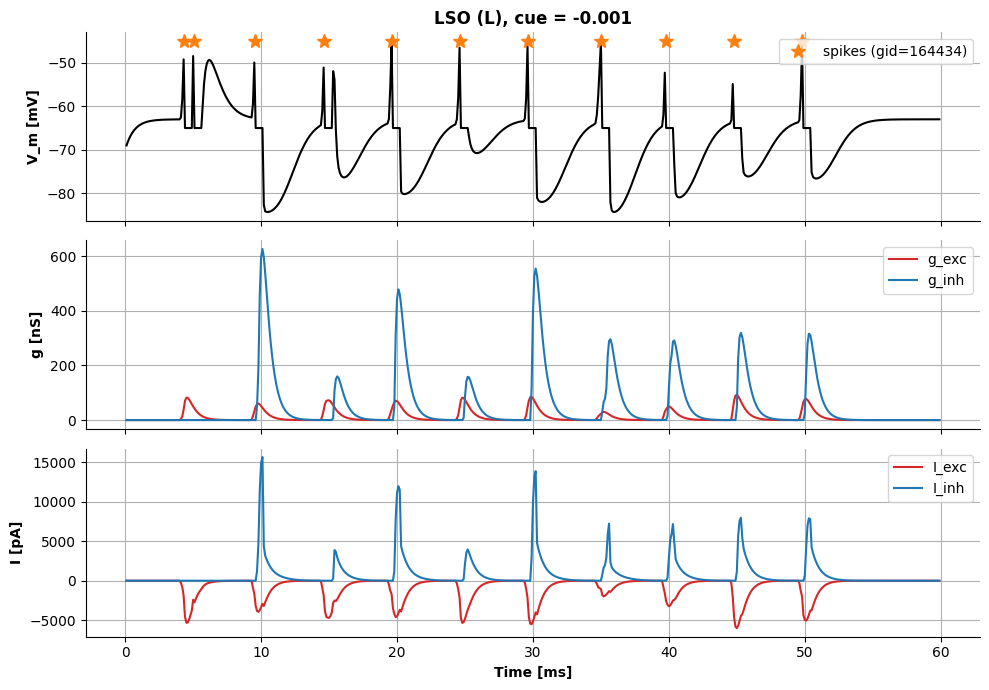

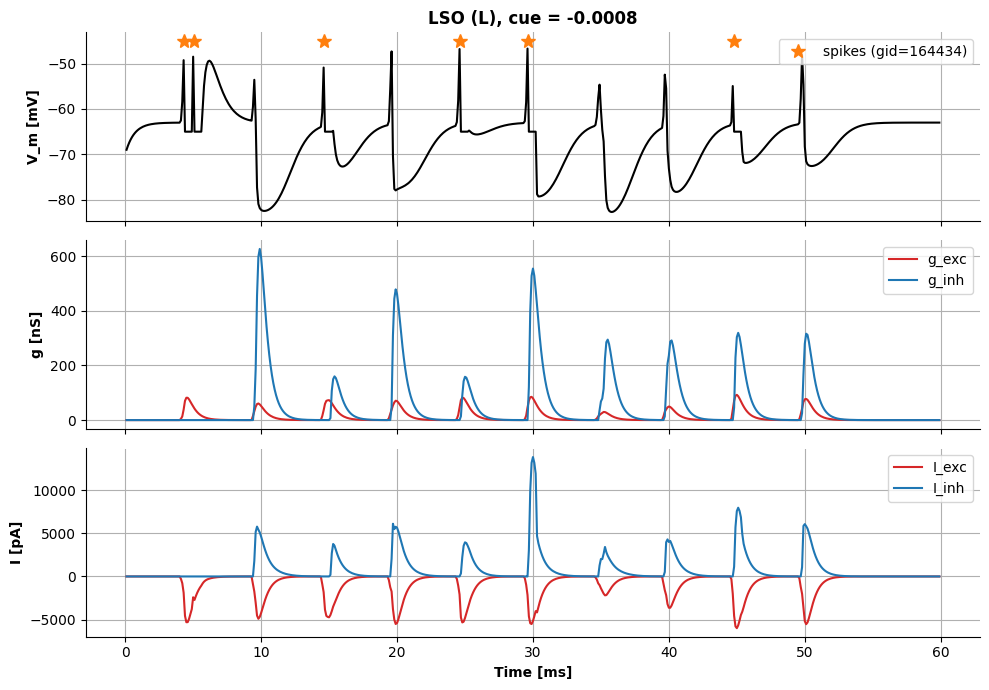

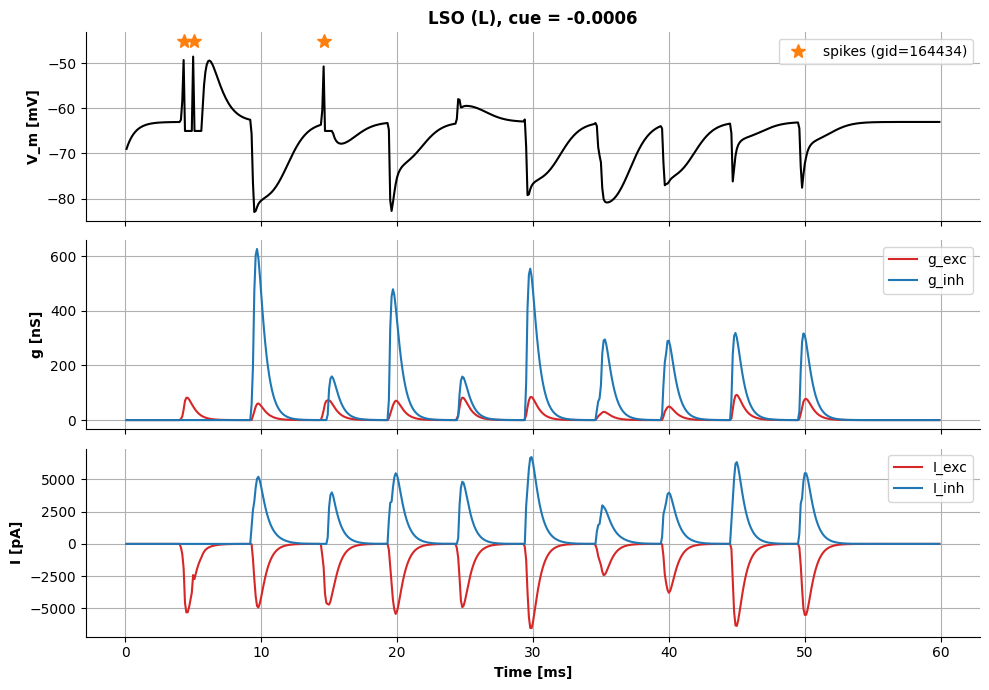

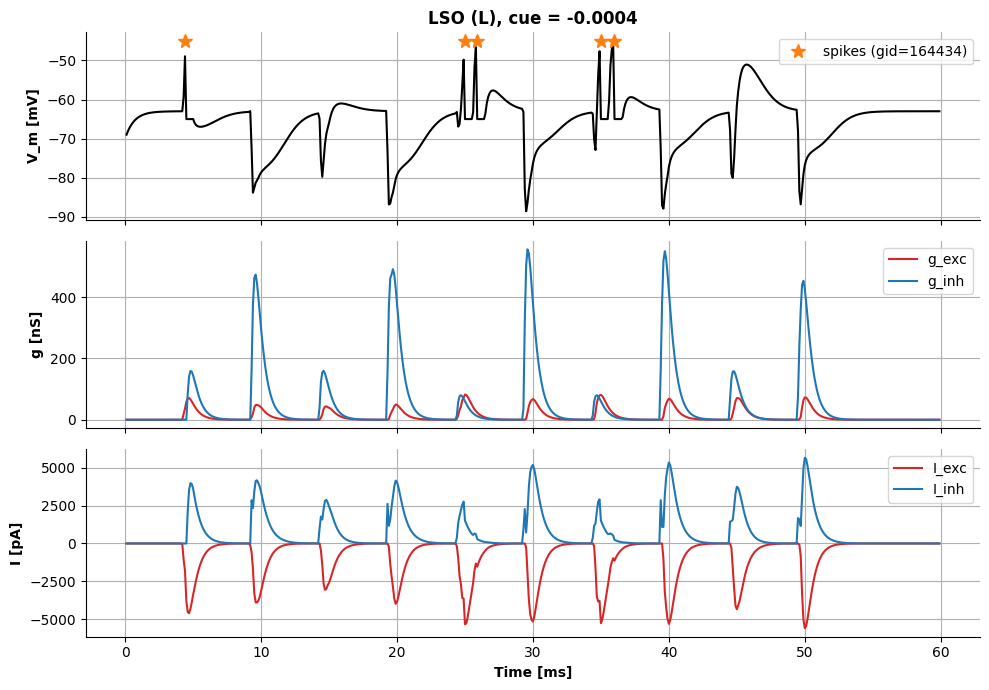

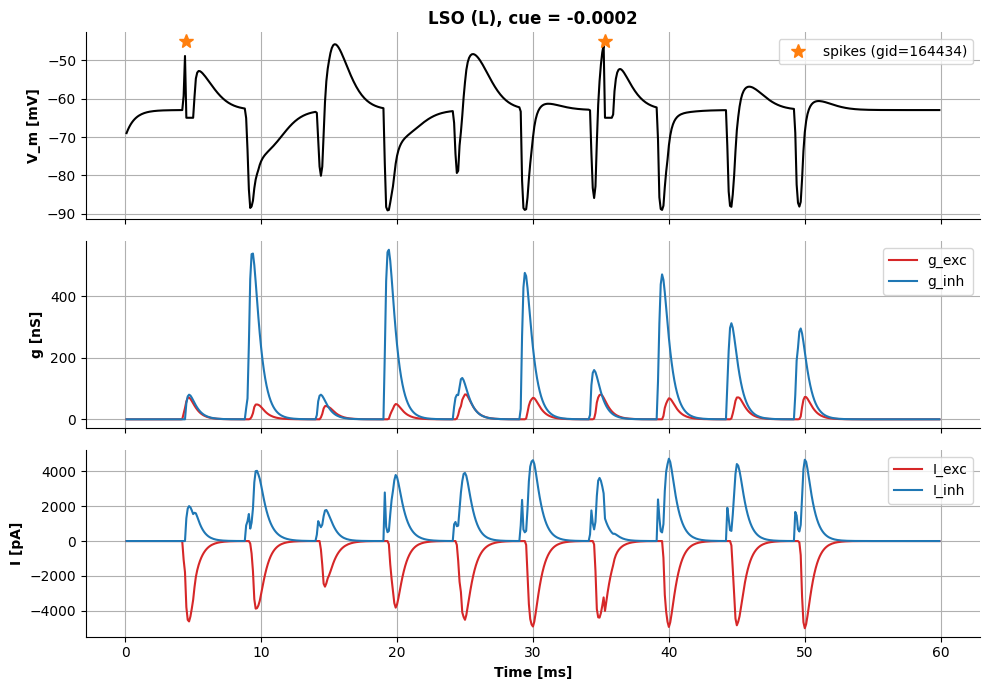

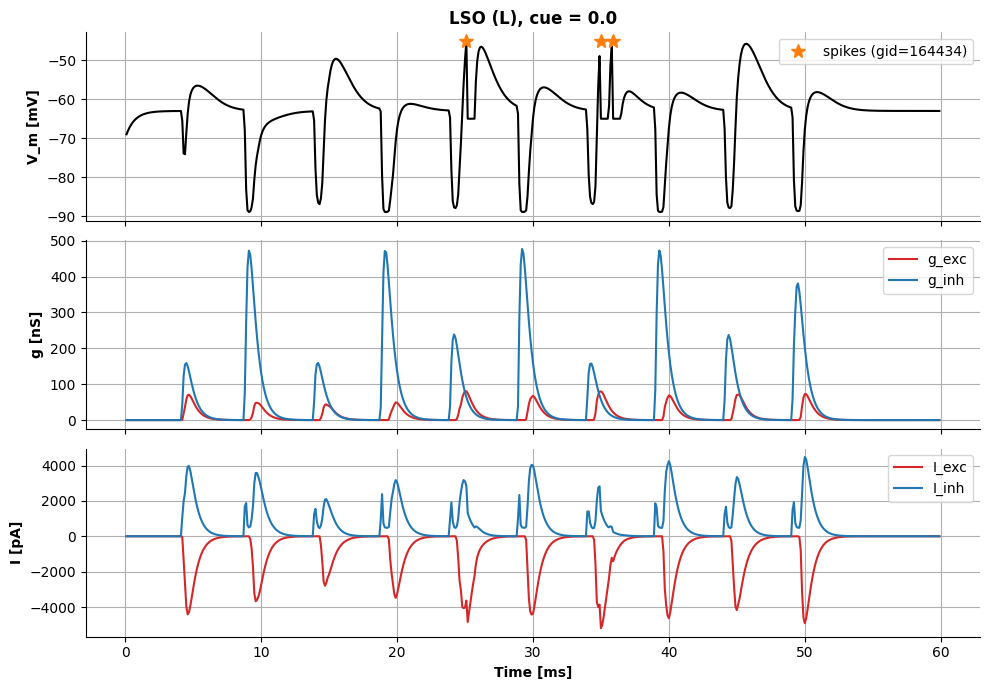

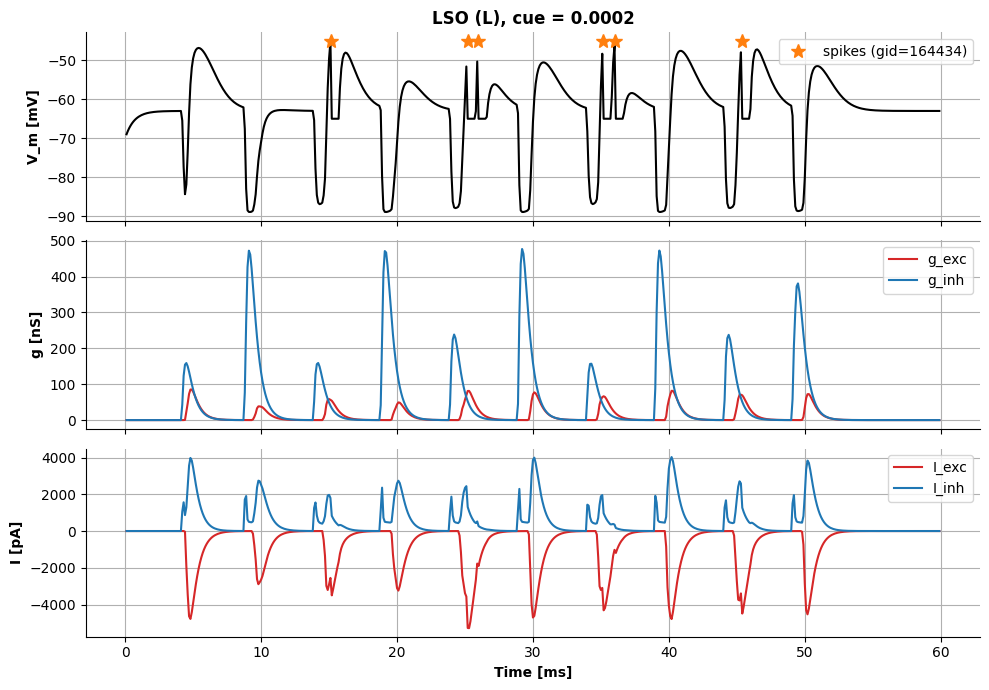

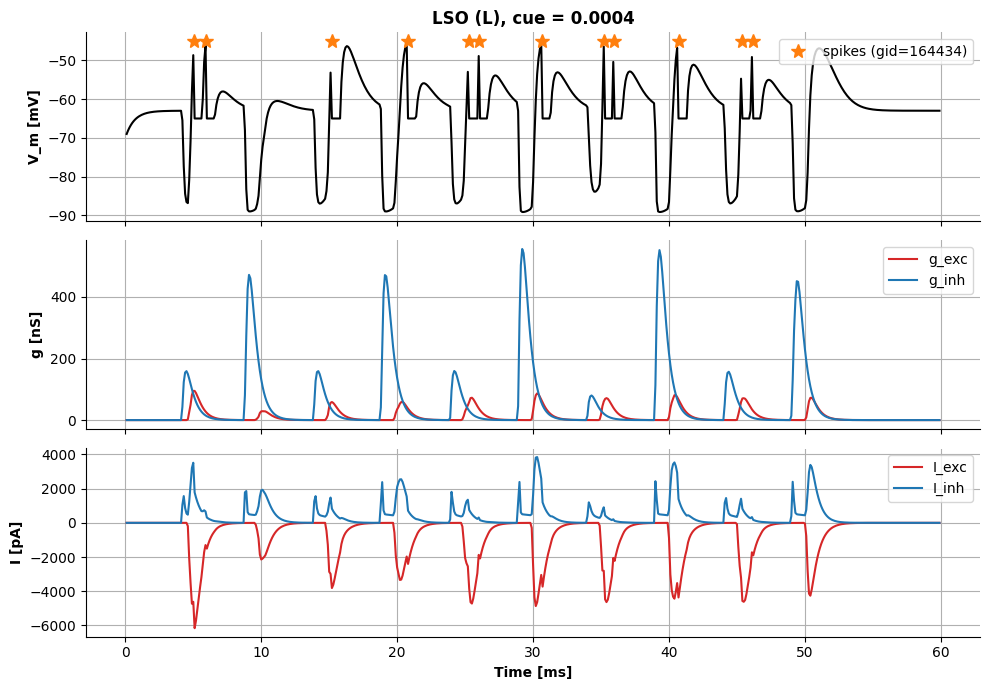

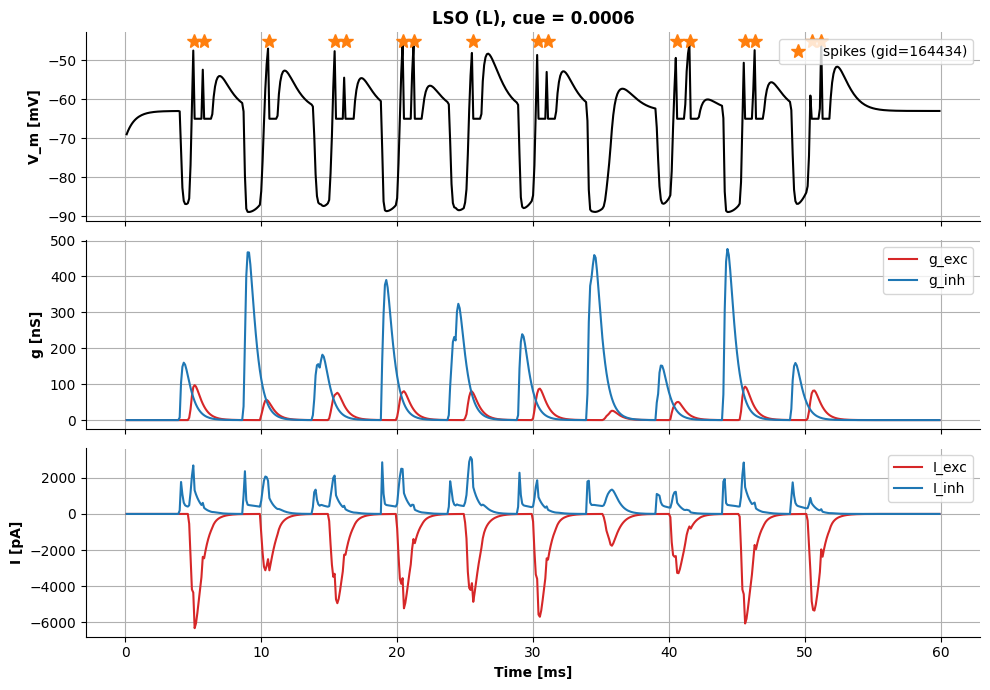

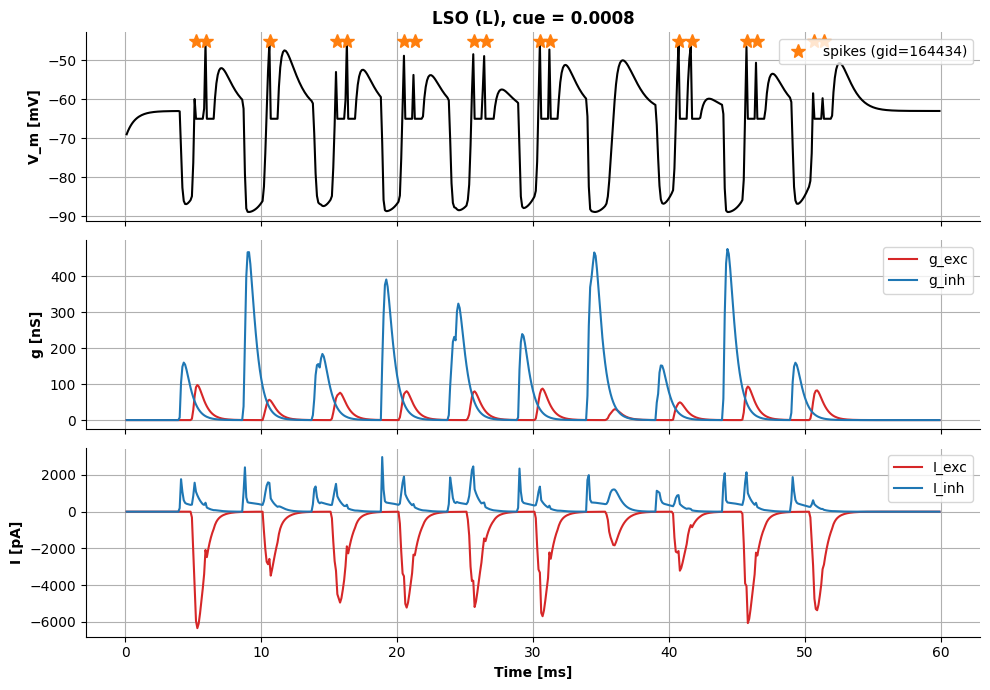

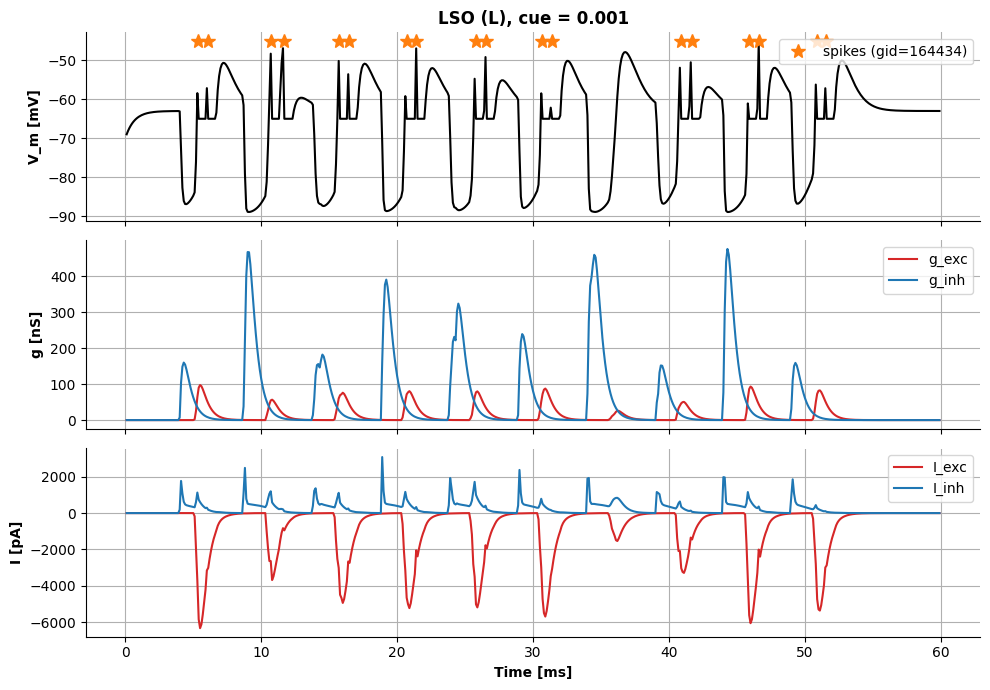

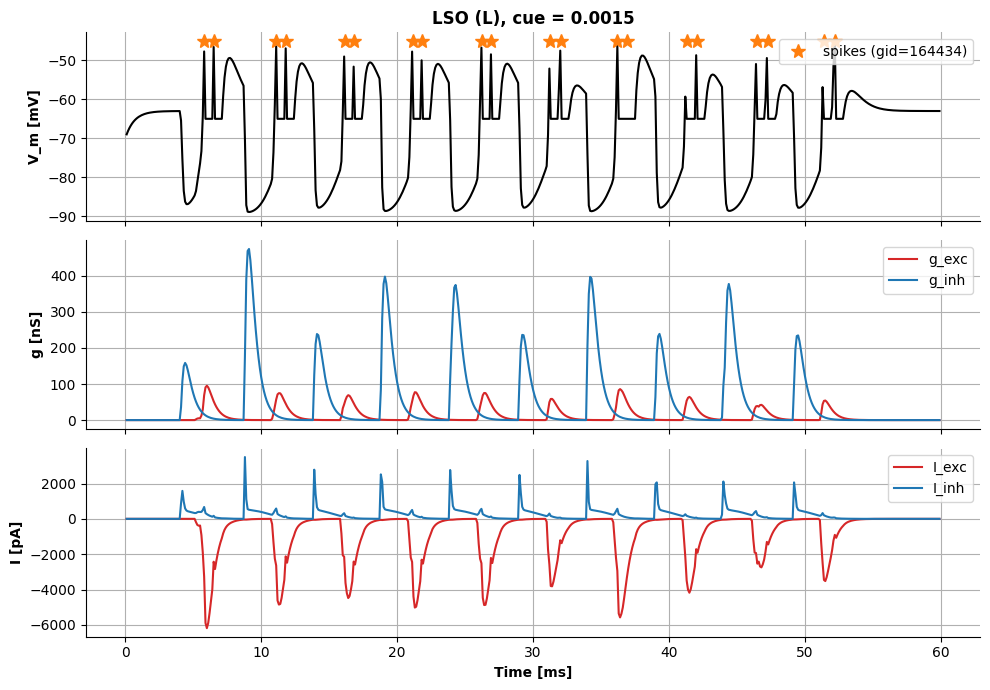

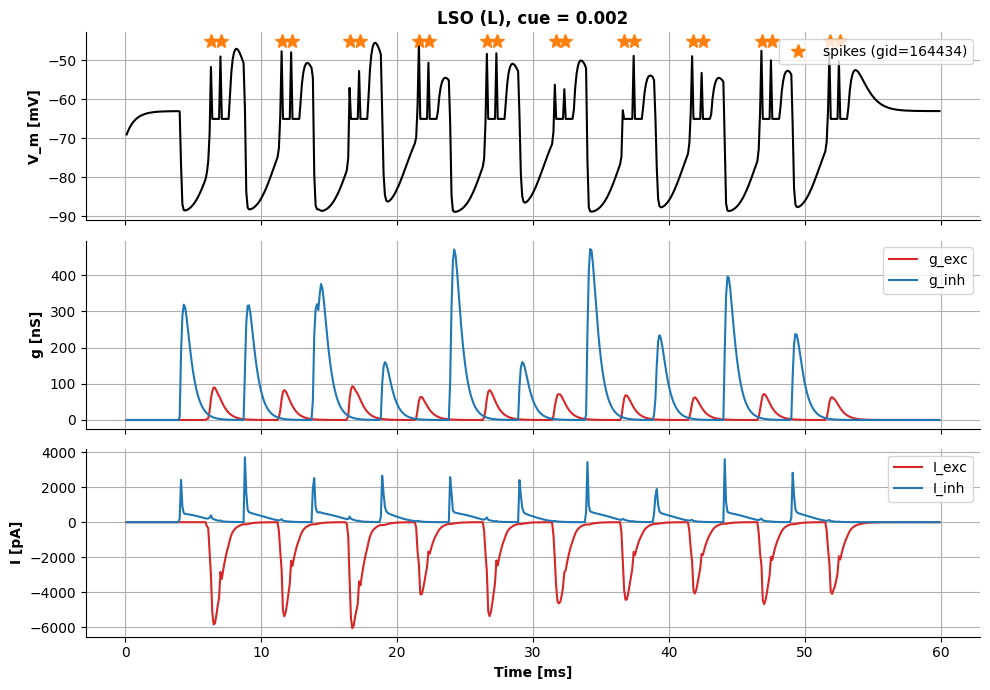

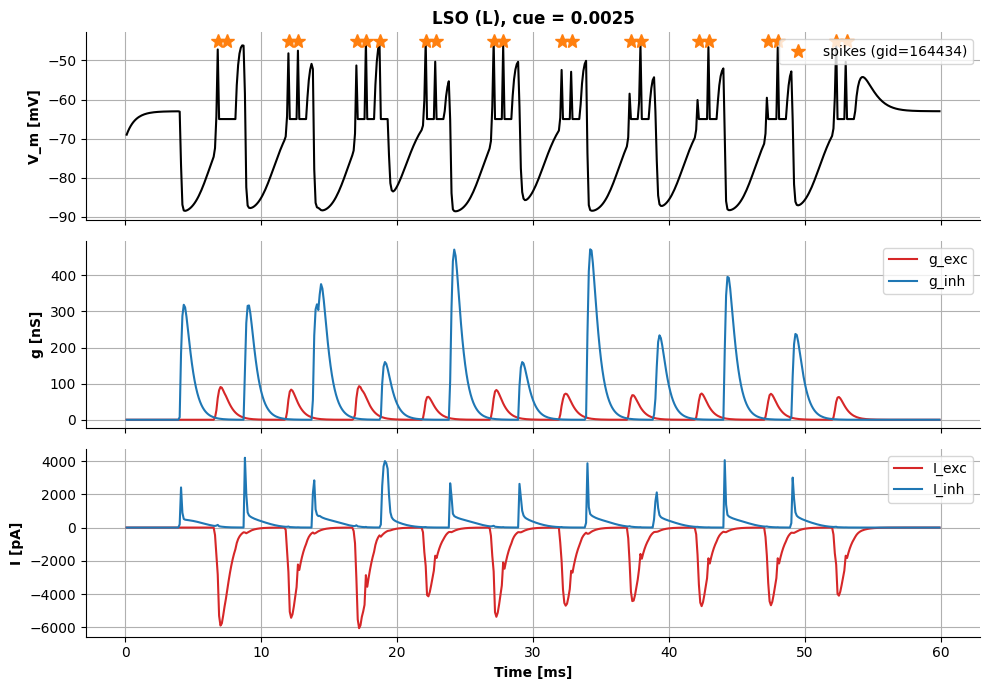

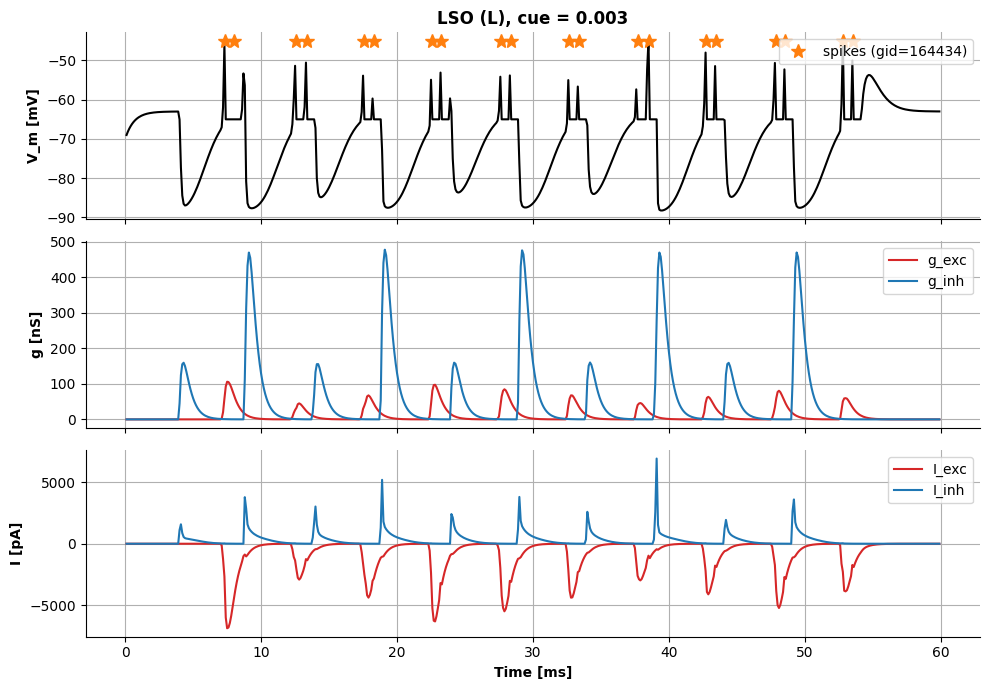

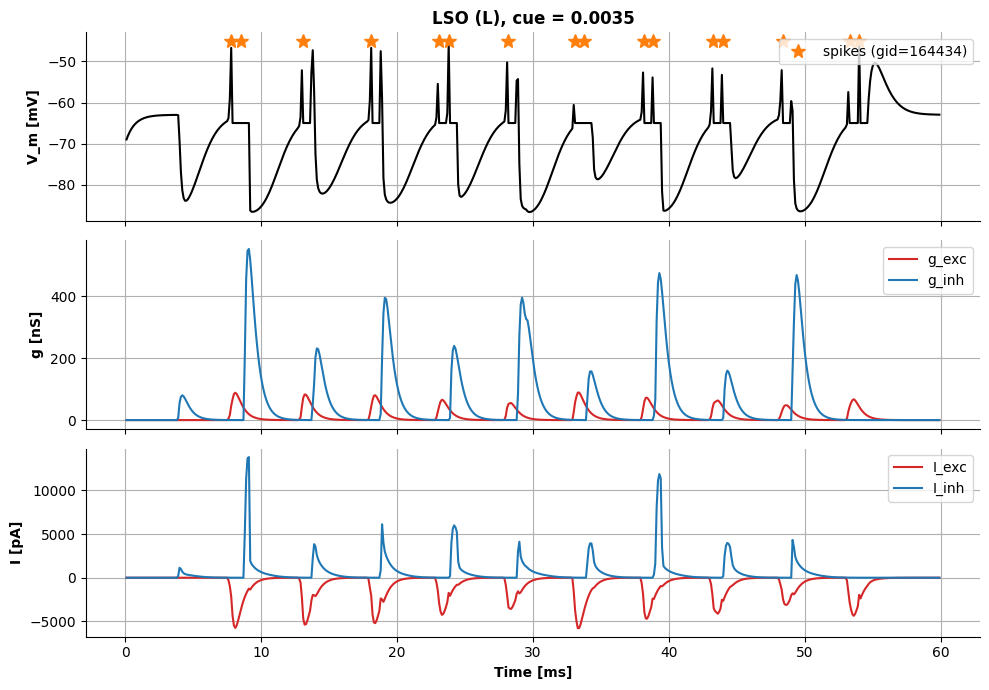

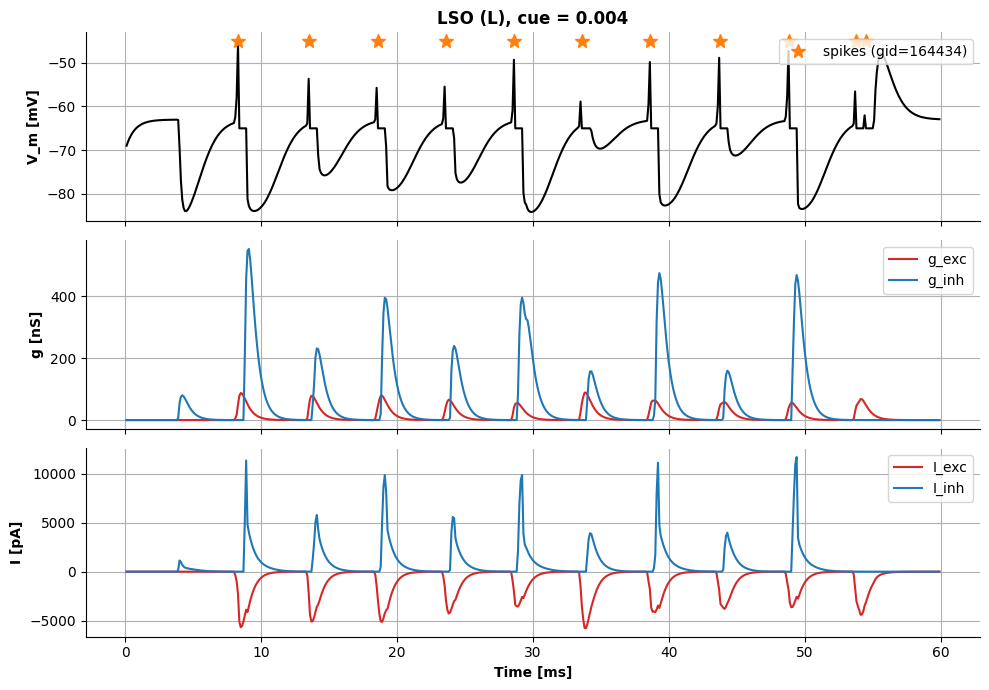

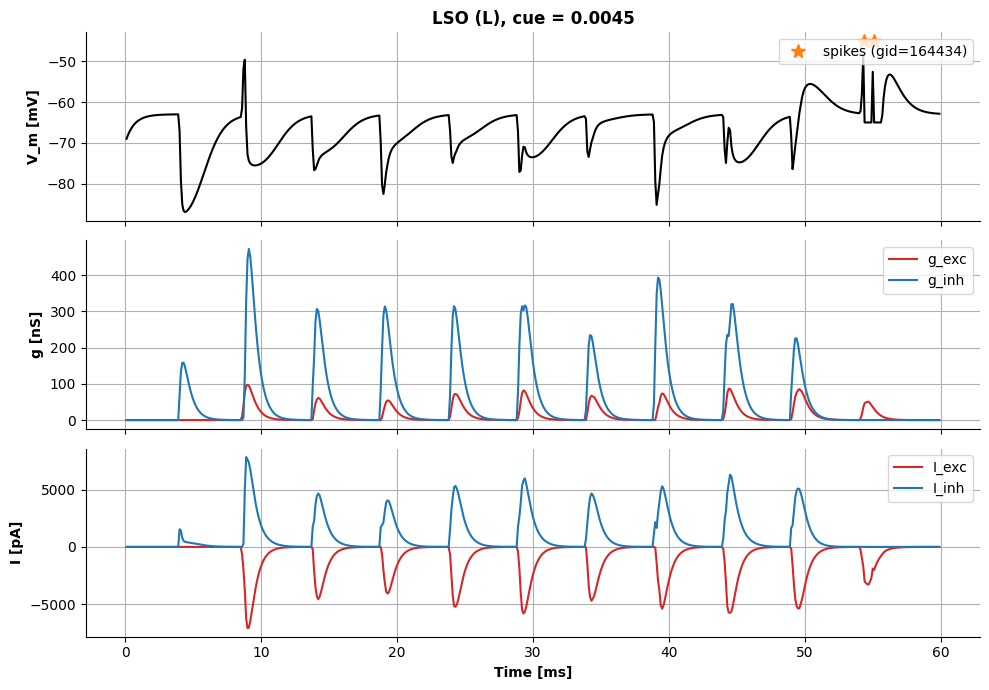

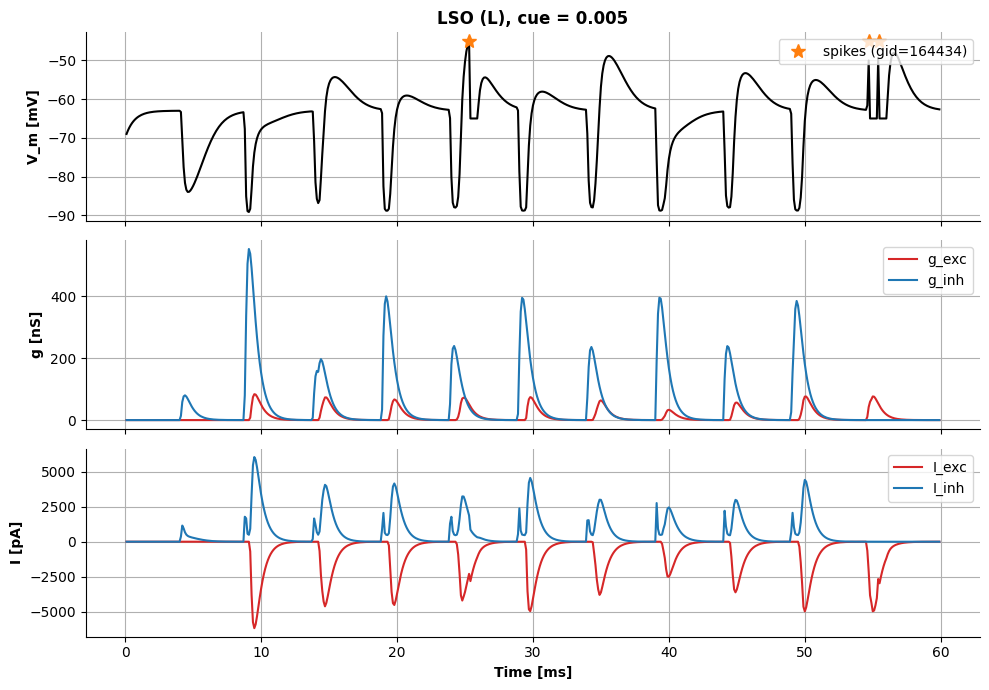

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

E_exc = 0.0    # mV
E_inh = -90.0  # mV
target_gid = 164434
spike_y = -45.0  # mV, fixed height for spike markers

for c in cue_values:
    data = result['cue_to_rate'][c]['L']['LSO_multimeter']
    t = data['times']
    v = data['V_m']
    g_exc = data['g_ex']
    g_in = data['g_in']

    # Synaptic currents: I = g * (V_m - E_rev)
    I_exc = g_exc * (v - E_exc)
    I_inh = g_in * (v - E_inh)

    # Extract spike times for the target neuron
    spike_data = result['cue_to_rate'][c]['L']['LSO']
    all_spike_times = np.array(spike_data['times'])
    all_spike_senders = np.array(spike_data['senders'])
    spike_times = all_spike_times[all_spike_senders == target_gid]

    fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

    ax[0].plot(t, v, color='k')
    ax[0].plot(spike_times, np.full_like(spike_times, spike_y),
               marker='*', linestyle='None', color='tab:orange',
               markersize=10, label=f'spikes (gid={target_gid})')
    ax[0].set_ylabel('V_m [mV]')
    ax[0].set_title(f'LSO (L), cue = {round(c,4)}')
    ax[0].legend(loc='upper right')

    ax[1].plot(t, g_exc, label='g_exc', color='tab:red')
    ax[1].plot(t, g_in, label='g_inh', color='tab:blue')
    ax[1].set_ylabel('g [nS]')
    ax[1].legend(loc='upper right')

    ax[2].plot(t, I_exc, label='I_exc', color='tab:red')
    ax[2].plot(t, I_inh, label='I_inh', color='tab:blue')
    ax[2].set_ylabel('I [pA]')
    ax[2].set_xlabel('Time [ms]')
    ax[2].legend(loc='upper right')

    fig.tight_layout()

plt.show()

[draw_rate_vs_cue_multidata] group '11000': target_cf_hz=11000 Hz → neuron idx 4818 → cf_interval=[10996.0, 10996.2] Hz
[draw_rate_vs_cue_multidata] group '12000': target_cf_hz=12000 Hz → neuron idx 4932 → cf_interval=[12002.5, 12002.7] Hz
[draw_rate_vs_cue_multidata] group '13000': target_cf_hz=13000 Hz → neuron idx 5036 → cf_interval=[12999.7, 12999.9] Hz
[draw_rate_vs_cue_multidata] group '14000': target_cf_hz=14000 Hz → neuron idx 5133 → cf_interval=[14003.2, 14003.4] Hz
[draw_rate_vs_cue_multidata] group '15000': target_cf_hz=15000 Hz → neuron idx 5223 → cf_interval=[15002.7, 15002.9] Hz
[draw_rate_vs_cue_multidata] group '16000': target_cf_hz=16000 Hz → neuron idx 5307 → cf_interval=[15999.0, 15999.2] Hz
[draw_rate_vs_cue_multidata] group '17000': target_cf_hz=17000 Hz → neuron idx 5386 → cf_interval=[16995.7, 16995.9] Hz
[draw_rate_vs_cue_multidata] group '18000': target_cf_hz=18000 Hz → neuron idx 5461 → cf_interval=[17998.7, 17998.9] Hz
[draw_rate_vs_cue_multidata] group '1900

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'LSO — side L (10 groups)'}, ylabel='Avg Firing Rate [Hz]'>)

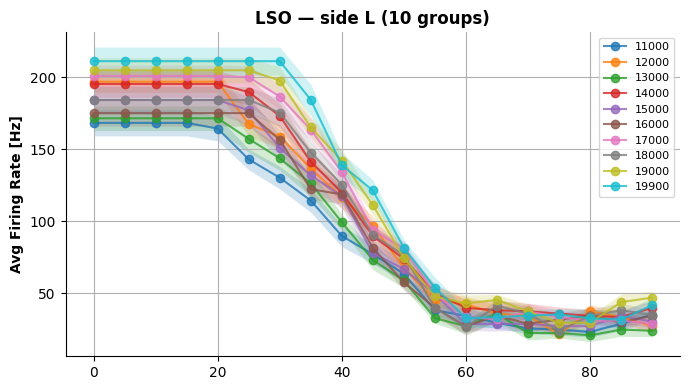

In [ ]:
from analyze.report import draw_rate_vs_cue_multidata
freqs = [11000,12000,13000,14000,15000,16000,17000,18000,19000,19900]
draw_rate_vs_cue_multidata(
    data_list= array,
    pop= pop,
    side='L',
    rate = 'avg',
    cue_type = x_ax,
    target_cf_hz = [f for f in freqs[:]],
    labels = freqs,
    # center_cf = freqs,
    # bw_neurons = 10,
    # cf_interval=cf_interval,
    # labels = ['c_MNTB = 11.8 pf [HOM %]', 'c_MNTB = 14.18 pf [HOM MEASURED]', 'c_MNTB = 22.72 pf [WT MEASURED]', 'c_MNTB = 18.9 pf [WT]'],
    # colors = [ '#ff7f0e', '#2ca02c', 'b', 'm'],
    # labels = ['we = 5, wi = -100', 'we = 5, wi = -80', 'we = 4, wi = -20', 'we = 5, wi = -150'],
)

In [ ]:
result = array[4][0]

print(result['filename'])


IndexError: list index out of range

In [ ]:
from analyze.report import draw_rate_vs_cue


draw_rate_vs_cue(
    data=results,
    pop= 'all',
    rate = True,
    cue_type = 'angle',
    cf_interval = cf_interval,
    time_interval = [0,100],
    )

ValueError: rate must be one of {'spk', 'spk_pn', 'max_norm', 'mm_norm', 'avg', 'pop'}, got True